# E-commerce Customer Analytics and Sales Forecasting
## Notebook 01 — Synthetic Dataset Generation

### Project Overview

In real-world e-commerce companies, data scientists rely heavily on transactional datasets to build machine learning models for:

- customer segmentation
- demand forecasting
- marketing optimization
- customer lifetime value modeling

However, most commercial datasets are proprietary and cannot be publicly shared.

For this reason, this project generates a **synthetic but realistic e-commerce dataset** designed to simulate the behavior of an online retail platform.

The generated dataset will later be used to build a complete end-to-end machine learning pipeline.

---

### Machine Learning Objectives

The generated dataset will support two major machine learning tasks:

**1. Customer Segmentation**

Clustering customers into groups based on purchasing behavior and engagement.

**2. Sales Forecasting**

Predicting future sales using time-series and machine learning models.

---

### Dataset Structure

The dataset contains two main tables.

#### Customer Table

Customer demographics and engagement:

- `customer_id`
- `age`
- `income`
- `country`
- `loyalty_member`
- `signup_date`
- `website_visits`
- `app_usage`
- `discount_usage`

---

#### Orders Table

Transaction-level data:

- `order_id`
- `customer_id`
- `order_date`
- `order_value`
- `product_category`
- `promotion`
- `holiday`
- `marketing_campaign`

---

### Realistic Data Patterns

The synthetic dataset simulates real e-commerce behavior including:

- seasonality
- weekend effects
- holiday spikes
- promotions
- customer heterogeneity
- platform growth
- random noise

---

### Notebook Steps

1. Environment setup
2. Configuration parameters
3. Customer dataset generation
4. Behavioral simulation
5. Order simulation engine
6. Order enrichment
7. Customer-level aggregations
8. Dataset validation
9. Export datasets

In [1]:
"""
Environment Setup

Initialize libraries and project directories.
"""

import os
import random
from datetime import datetime, timedelta

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Visualization style
sns.set_style("whitegrid")

# Pandas display
pd.set_option("display.max_columns", None)

print("Environment initialized.")

Environment initialized.


In [2]:
"""
Project Folder Structure

Create folders for datasets and figures.
"""

os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

os.makedirs("../figures/dataset_validation", exist_ok=True)
os.makedirs("../figures/exploratory_analysis", exist_ok=True)

print("Project folders created.")

Project folders created.


### Project Configuration

In this section we define the global parameters used for the synthetic data generation.

Centralizing configuration improves:

- reproducibility
- maintainability
- scalability of the dataset

In [3]:
"""
Global Parameters
"""

N_CUSTOMERS = 10000
N_DAYS = 730

START_DATE = datetime(2023,1,1)
END_DATE = START_DATE + timedelta(days=N_DAYS)

AGE_MIN = 18
AGE_MAX = 75

LOYALTY_PROBABILITY = 0.35

BASE_PURCHASE_PROBABILITY = 0.05

print("Configuration loaded.")

Configuration loaded.


## Customer Dataset Generation

In this section we generate the **base customer dataset**.

Customer attributes represent demographic and engagement characteristics that will later influence purchasing behavior.

### Generated Features

The following variables will be created:

**Customer identifiers**

- `customer_id`
- `signup_date`

**Demographics**

- `age`
- `income`
- `country`
- `loyalty_member`

### Realistic Patterns Introduced

To simulate realistic e-commerce environments, we include:

**Platform growth**

Customer acquisition tends to increase as the platform grows.

**Income distribution**

Income typically follows a **log-normal distribution** rather than a normal distribution.

**Market concentration**

Certain countries will have a larger share of customers than others.

These features will later influence:

- purchase propensity
- average order value
- engagement behavior

In [4]:
"""
Customer Generation — IDs and Signup Dates
"""

# Generate customer IDs
customer_ids = np.arange(1, N_CUSTOMERS + 1)

# Simulate platform growth using beta distribution
signup_curve = np.random.beta(a=2, b=5, size=N_CUSTOMERS)

signup_days = signup_curve * N_DAYS

signup_dates = [
    START_DATE + timedelta(days=int(day))
    for day in signup_days
]

# Create base dataframe
customers = pd.DataFrame({
    "customer_id": customer_ids,
    "signup_date": signup_dates
})

# Sort chronologically
customers = customers.sort_values("signup_date").reset_index(drop=True)

customers.head()

,customer_id,signup_date
0,6173,2023-01-01
1,7128,2023-01-03
2,4220,2023-01-03
3,1120,2023-01-04
4,2020,2023-01-05


In [5]:
"""
Customer Generation — Demographics
"""

# Age distribution
ages = np.random.normal(loc=35, scale=10, size=N_CUSTOMERS)
ages = np.clip(ages, AGE_MIN, AGE_MAX)

# Income distribution (log-normal)
income = np.random.lognormal(
    mean=np.log(50000),
    sigma=0.5,
    size=N_CUSTOMERS
)

# Country distribution
countries = [
    "Spain",
    "France",
    "Germany",
    "Italy",
    "Portugal",
    "Netherlands"
]

country_probs = [0.35, 0.18, 0.18, 0.14, 0.10, 0.05]

country_sample = np.random.choice(
    countries,
    size=N_CUSTOMERS,
    p=country_probs
)

# Loyalty membership
loyalty_member = np.random.binomial(
    1,
    LOYALTY_PROBABILITY,
    size=N_CUSTOMERS
)

# Assign features
customers["age"] = ages.astype(int)
customers["income"] = income.astype(int)
customers["country"] = country_sample
customers["loyalty_member"] = loyalty_member.astype(bool)

customers.head()

,customer_id,signup_date,age,income,country,loyalty_member
0,6173,2023-01-01,38,70953,Portugal,True
1,7128,2023-01-03,21,42602,Spain,True
2,4220,2023-01-03,40,30478,France,False
3,1120,2023-01-04,52,22415,Portugal,True
4,2020,2023-01-05,51,39682,Italy,False


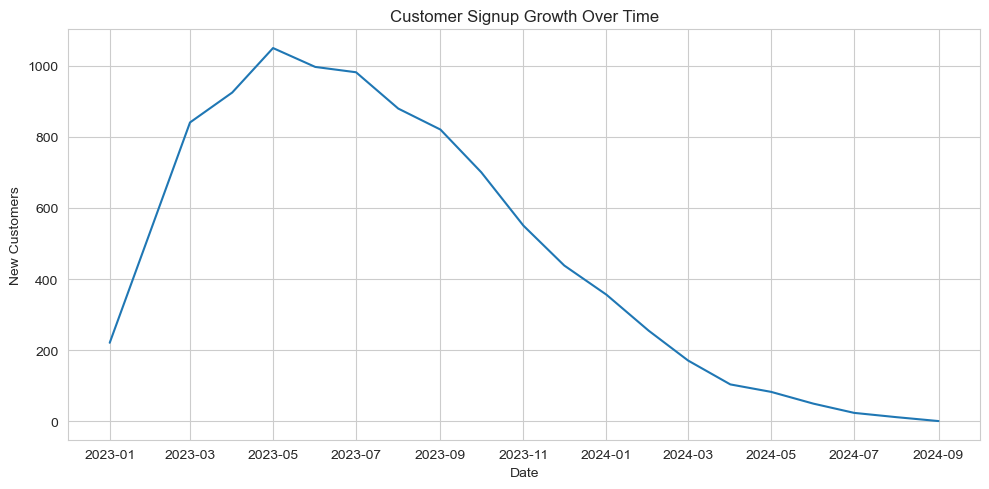

In [6]:
"""
Dataset Validation — Customer Signup Growth
"""

signup_counts = (
    customers
    .groupby(customers["signup_date"].dt.to_period("M"))
    .size()
)

signup_counts.index = signup_counts.index.to_timestamp()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=signup_counts.index,
    y=signup_counts.values
)

plt.title("Customer Signup Growth Over Time")
plt.xlabel("Date")
plt.ylabel("New Customers")

plt.tight_layout()

plt.savefig(
    "../figures/dataset_validation/customer_signup_growth.png",
    dpi=300
)

plt.show()

## Customer Behavioral Simulation

After generating the demographic attributes of customers, we simulate **engagement behavior** with the e-commerce platform.

Customer engagement is a key factor in many machine learning applications such as:

- purchase prediction
- churn modeling
- marketing optimization
- customer segmentation

### Behavioral Variables

We simulate several behavioral signals commonly tracked by e-commerce platforms.

**Platform engagement**

- `website_visits`
- `app_usage`

**Promotional sensitivity**

- `discount_usage`

**Engagement score**

A synthetic score combining multiple engagement signals.

**Purchase propensity**

A probabilistic score representing how likely a customer is to make a purchase.

This variable will later influence the **order simulation process**.

In [7]:
"""
Customer Behavior — Engagement Metrics
"""

# Website visits (Poisson distribution)
website_visits = np.random.poisson(
    lam=8,
    size=N_CUSTOMERS
)

# App usage (Poisson distribution)
app_usage = np.random.poisson(
    lam=4,
    size=N_CUSTOMERS
)

# Discount sensitivity
discount_usage = np.random.binomial(
    1,
    0.4,
    size=N_CUSTOMERS
)

customers["website_visits"] = website_visits
customers["app_usage"] = app_usage
customers["discount_usage"] = discount_usage.astype(bool)

customers.head()

,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False
1,7128,2023-01-03,21,42602,Spain,True,11,4,True
2,4220,2023-01-03,40,30478,France,False,12,2,True
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True
4,2020,2023-01-05,51,39682,Italy,False,9,4,False


In [8]:
"""
Customer Behavior — Engagement Score
"""

# Normalize engagement signals
visits_scaled = customers["website_visits"] / customers["website_visits"].max()
app_scaled = customers["app_usage"] / customers["app_usage"].max()

discount_factor = customers["discount_usage"].astype(int)

engagement_score = (
    0.5 * visits_scaled +
    0.3 * app_scaled +
    0.2 * discount_factor
)

# Add noise
noise = np.random.normal(0, 0.05, N_CUSTOMERS)

customers["engagement_score"] = np.clip(
    engagement_score + noise,
    0,
    1
)

customers.head()

,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583


In [9]:
"""
Customer Behavior — Purchase Propensity
"""

income_scaled = customers["income"] / customers["income"].max()
loyalty_factor = customers["loyalty_member"].astype(int)

propensity = (
    0.35 * customers["engagement_score"] +
    0.30 * income_scaled +
    0.20 * loyalty_factor +
    0.15 * customers["discount_usage"].astype(int)
)

noise = np.random.normal(0, 0.03, N_CUSTOMERS)

customers["purchase_propensity"] = np.clip(
    propensity + noise,
    0,
    1
)

customers.head()

,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score,purchase_propensity
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216,0.369702
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138,0.493732
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699,0.320223
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599,0.575448
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583,0.136320


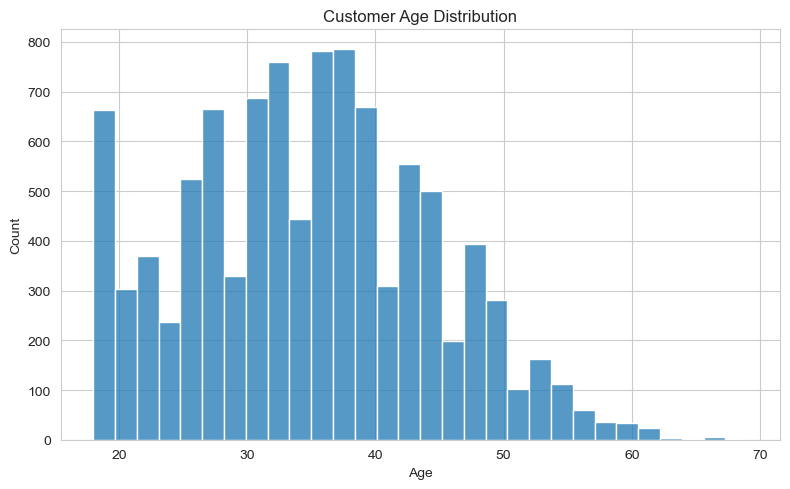

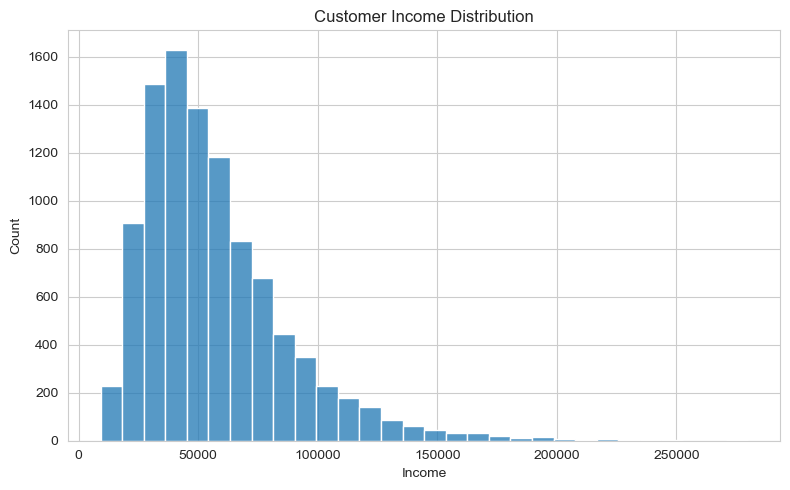

In [10]:
"""
Dataset Validation — Customer Distributions
"""

# Age distribution
plt.figure(figsize=(8,5))

sns.histplot(customers["age"], bins=30)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../figures/dataset_validation/customer_age_distribution.png",
    dpi=300
)

plt.show()


# Income distribution
plt.figure(figsize=(8,5))

sns.histplot(customers["income"], bins=30)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../figures/dataset_validation/customer_income_distribution.png",
    dpi=300
)

plt.show()

## Calendar and Seasonality Simulation

E-commerce sales follow strong **temporal patterns**. Understanding these patterns is essential for:

- demand forecasting
- promotion planning
- inventory management
- marketing optimization

To simulate realistic time-series behavior, we create a **calendar table** containing temporal features and special events.

### Temporal Features

The calendar table will include:

- `order_date`
- `year`
- `month`
- `day`
- `day_of_week`
- `week_of_year`
- `is_weekend`

### Special Events

We simulate several important commercial events:

**Black Friday**

Major global shopping event with extremely high sales.

**Christmas Period**

Increased purchases during the holiday season.

**Summer Sale**

Seasonal promotions common in retail.

### Demand Multipliers

Each day will have a **demand multiplier** that modifies the expected number of orders.

Examples:

- weekends → increased purchases
- promotions → higher conversion rates
- holidays → strong demand spikes

In [11]:
"""
Calendar Generation
"""

date_range = pd.date_range(
    start=START_DATE,
    end=END_DATE
)

calendar = pd.DataFrame({
    "order_date": date_range
})

calendar["year"] = calendar["order_date"].dt.year
calendar["month"] = calendar["order_date"].dt.month
calendar["day"] = calendar["order_date"].dt.day
calendar["day_of_week"] = calendar["order_date"].dt.dayofweek

calendar["week_of_year"] = calendar["order_date"].dt.isocalendar().week.astype(int)

calendar["is_weekend"] = calendar["day_of_week"].isin([5,6])

calendar.head()

,order_date,year,month,day,day_of_week,week_of_year,is_weekend
0,2023-01-01,2023,1,1,6,52,True
1,2023-01-02,2023,1,2,0,1,False
2,2023-01-03,2023,1,3,1,1,False
3,2023-01-04,2023,1,4,2,1,False
4,2023-01-05,2023,1,5,3,1,False


In [12]:
"""
Calendar Events — Promotions and Holidays
"""

calendar["promotion"] = False
calendar["holiday"] = None

# Black Friday (last Friday of November)

black_friday = (
    calendar[
        (calendar["month"] == 11) &
        (calendar["day_of_week"] == 4)
    ]
    .groupby("year")
    .tail(1)
)

calendar.loc[black_friday.index, "holiday"] = "Black Friday"
calendar.loc[black_friday.index, "promotion"] = True


# Christmas shopping period

christmas_mask = (
    (calendar["month"] == 12) &
    (calendar["day"] >= 20)
)

calendar.loc[christmas_mask, "holiday"] = "Christmas"
calendar.loc[christmas_mask, "promotion"] = True


# Summer sale

summer_mask = (
    calendar["month"] == 7
)

calendar.loc[summer_mask, "promotion"] = True

calendar.sample(10)

,order_date,year,month,day,day_of_week,week_of_year,is_weekend,promotion,holiday
378,2024-01-14,2024,1,14,6,2,True,False,None
482,2024-04-27,2024,4,27,5,17,True,False,None
207,2023-07-27,2023,7,27,3,30,False,True,None
21,2023-01-22,2023,1,22,6,3,True,False,None
203,2023-07-23,2023,7,23,6,29,True,True,None
129,2023-05-10,2023,5,10,2,19,False,False,None
547,2024-07-01,2024,7,1,0,27,False,True,None
591,2024-08-14,2024,8,14,2,33,False,False,None
603,2024-08-26,2024,8,26,0,35,False,False,None
578,2024-08-01,2024,8,1,3,31,False,False,None


In [13]:
"""
Demand Multipliers
"""

def compute_demand_multiplier(row):
    
    multiplier = 1.0
    
    # Weekend boost
    if row["is_weekend"]:
        multiplier *= 1.2
        
    # Summer sale boost
    if row["month"] == 7:
        multiplier *= 1.3
        
    # Black Friday spike
    if row["holiday"] == "Black Friday":
        multiplier *= 3.5
        
    # Christmas demand
    if row["holiday"] == "Christmas":
        multiplier *= 2.5
        
    return multiplier


calendar["demand_multiplier"] = calendar.apply(
    compute_demand_multiplier,
    axis=1
)

calendar.head()

,order_date,year,month,day,day_of_week,week_of_year,is_weekend,promotion,holiday,demand_multiplier
0,2023-01-01,2023,1,1,6,52,True,False,None,1.2
1,2023-01-02,2023,1,2,0,1,False,False,None,1.0
2,2023-01-03,2023,1,3,1,1,False,False,None,1.0
3,2023-01-04,2023,1,4,2,1,False,False,None,1.0
4,2023-01-05,2023,1,5,3,1,False,False,None,1.0


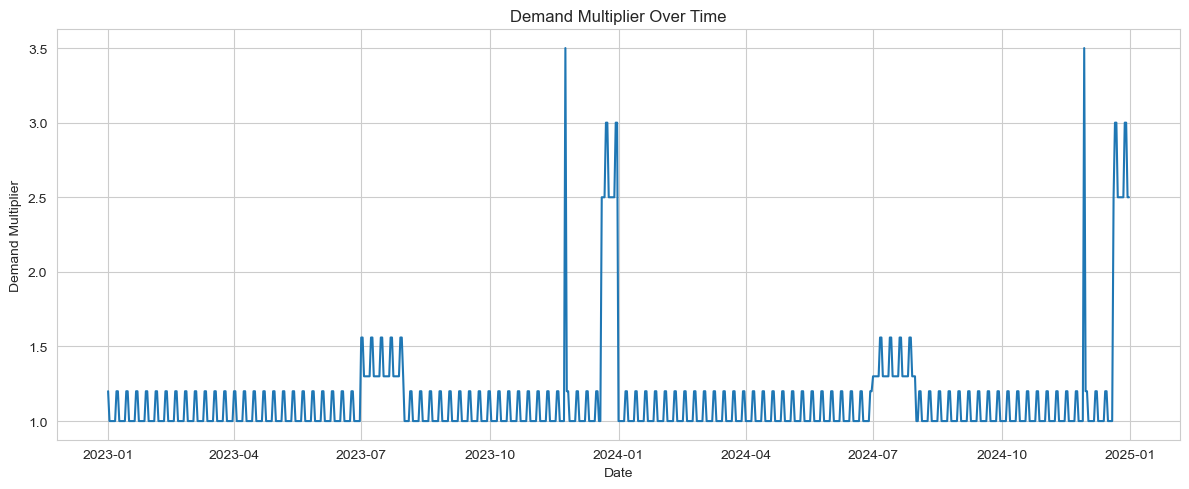

In [14]:
"""
Dataset Validation — Demand Multiplier Over Time
"""

plt.figure(figsize=(12,5))

sns.lineplot(
    x=calendar["order_date"],
    y=calendar["demand_multiplier"]
)

plt.title("Demand Multiplier Over Time")
plt.xlabel("Date")
plt.ylabel("Demand Multiplier")

plt.tight_layout()

plt.savefig(
    "../figures/dataset_validation/demand_multiplier_over_time.png",
    dpi=300
)

plt.show()

## Order Simulation Engine

This section generates the **transaction-level dataset**.

Each order represents a purchase made by a customer on a specific day.

The simulation combines several factors to determine daily demand:

### Customer Behavior

Customers with higher **purchase propensity** are more likely to place orders.

### Seasonality

Demand is influenced by:

- weekends
- promotions
- holidays

### Platform Growth

As the platform grows, overall sales volume tends to increase over time.

### Random Noise

Random variation is introduced to avoid unrealistic deterministic patterns.

### Generated Variables

Each simulated order will contain:

- `order_id`
- `customer_id`
- `order_date`
- `promotion`
- `holiday`

Additional order attributes will be added later:

- product category
- order value
- marketing campaign

In [15]:
"""
Order Simulation Configuration
"""

# Container for simulated orders
orders_list = []

order_id_counter = 1

# Base expected daily orders
base_daily_orders = int(N_CUSTOMERS * BASE_PURCHASE_PROBABILITY)

# Growth factor (platform growth over time)
daily_growth_rate = 0.0005

print("Base daily orders:", base_daily_orders)

Base daily orders: 500


In [16]:
"""
Order Simulation Loop
"""

# Precompute sampling weights
weights = customers["purchase_propensity"].values
weights = weights / weights.sum()

for i, day in calendar.iterrows():
    
    # Growth trend
    growth_multiplier = 1 + (i * daily_growth_rate)
    
    # Adjust demand
    expected_orders = int(
        base_daily_orders *
        day["demand_multiplier"] *
        growth_multiplier
    )
    
    # Add randomness
    n_orders = np.random.poisson(expected_orders)
    
    # Sample customers
    sampled_customers = np.random.choice(
        customers["customer_id"],
        size=n_orders,
        replace=True,
        p=weights
    )
    
    for customer_id in sampled_customers:
        
        orders_list.append({
            "order_id": order_id_counter,
            "customer_id": customer_id,
            "order_date": day["order_date"],
            "promotion": day["promotion"],
            "holiday": day["holiday"]
        })
        
        order_id_counter += 1

print("Total simulated orders:", len(orders_list))

Total simulated orders: 495949


In [17]:
"""
Create Orders DataFrame
"""

orders = pd.DataFrame(orders_list)

orders.head()

,order_id,customer_id,order_date,promotion,holiday
0,1,8704,2023-01-01,False,None
1,2,7660,2023-01-01,False,None
2,3,308,2023-01-01,False,None
3,4,7076,2023-01-01,False,None
4,5,9468,2023-01-01,False,None


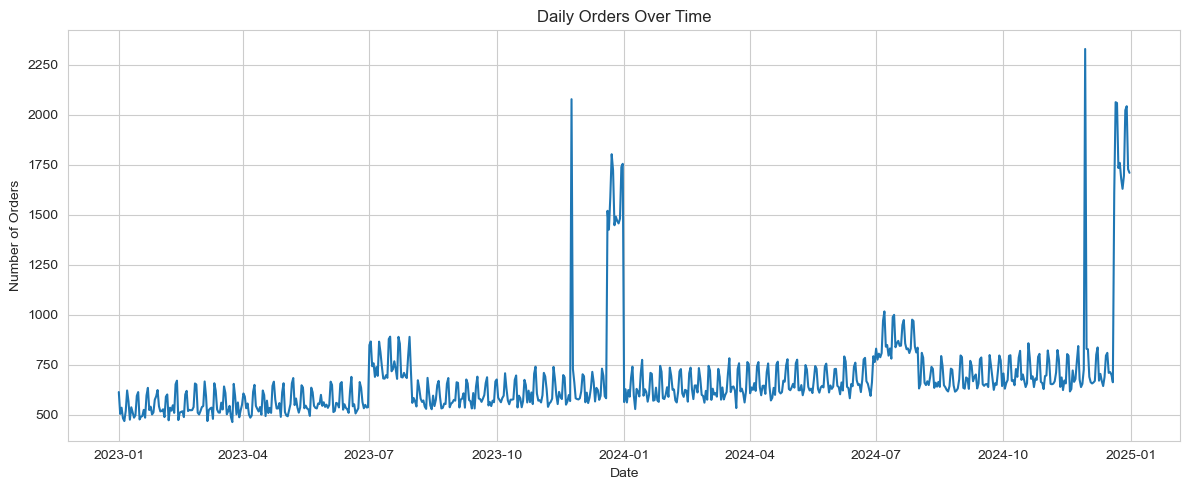

In [18]:
"""
Dataset Validation — Orders Per Day
"""

orders_per_day = (
    orders
    .groupby("order_date")
    .size()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=orders_per_day.index,
    y=orders_per_day.values
)

plt.title("Daily Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../figures/dataset_validation/orders_per_day.png",
    dpi=300
)

plt.show()

## Order Enrichment

After generating the core transaction records, we now enrich the orders with additional attributes that reflect real e-commerce data.

### Product Information

Each order will include a product category such as:

- Electronics
- Fashion
- Home
- Beauty
- Sports
- Toys
- Books

These categories will have different purchase frequencies.

### Order Value Modeling

Order values depend on the product category.

For example:

- electronics → higher average value
- books → lower average value

Promotions will slightly reduce the final order price.

### Marketing Attribution

Orders will be associated with marketing channels such as:

- Email
- Paid Ads
- Social Media
- Affiliate
- Influencer
- Organic

This information is useful for marketing analytics and attribution modeling.

In [19]:
"""
Assign product categories to orders
"""

product_categories = [
    "Electronics",
    "Fashion",
    "Home",
    "Beauty",
    "Sports",
    "Toys",
    "Books"
]

category_probs = [
    0.18,
    0.25,
    0.16,
    0.14,
    0.10,
    0.09,
    0.08
]

orders["product_category"] = np.random.choice(
    product_categories,
    size=len(orders),
    p=category_probs
)

orders.head()

,order_id,customer_id,order_date,promotion,holiday,product_category
0,1,8704,2023-01-01,False,None,Toys
1,2,7660,2023-01-01,False,None,Beauty
2,3,308,2023-01-01,False,None,Books
3,4,7076,2023-01-01,False,None,Electronics
4,5,9468,2023-01-01,False,None,Toys


In [20]:
"""
Order Value Modeling
"""

category_price_params = {
    "Electronics": (5.5, 0.6),
    "Fashion": (4.2, 0.5),
    "Home": (4.5, 0.5),
    "Beauty": (3.5, 0.4),
    "Sports": (4.3, 0.5),
    "Toys": (3.8, 0.4),
    "Books": (3.0, 0.3)
}

order_values = []

for _, row in orders.iterrows():
    
    mean, sigma = category_price_params[row["product_category"]]
    
    value = np.random.lognormal(mean, sigma)
    
    # Promotion discount
    if row["promotion"]:
        value *= np.random.uniform(0.75, 0.9)
        
    order_values.append(value)

orders["order_value"] = np.round(order_values, 2)

orders.head()

,order_id,customer_id,order_date,promotion,holiday,product_category,order_value
0,1,8704,2023-01-01,False,None,Toys,47.85
1,2,7660,2023-01-01,False,None,Beauty,36.99
2,3,308,2023-01-01,False,None,Books,15.03
3,4,7076,2023-01-01,False,None,Electronics,177.16
4,5,9468,2023-01-01,False,None,Toys,36.79


In [21]:
"""
Marketing Campaign Attribution
"""

campaigns = [
    "Email",
    "Paid Ads",
    "Social Media",
    "Affiliate",
    "Influencer",
    "Organic"
]

campaign_probs = [
    0.22,
    0.28,
    0.18,
    0.12,
    0.08,
    0.12
]

orders["marketing_campaign"] = np.random.choice(
    campaigns,
    size=len(orders),
    p=campaign_probs
)

orders.head()

,order_id,customer_id,order_date,promotion,holiday,product_category,order_value,marketing_campaign
0,1,8704,2023-01-01,False,None,Toys,47.85,Paid Ads
1,2,7660,2023-01-01,False,None,Beauty,36.99,Paid Ads
2,3,308,2023-01-01,False,None,Books,15.03,Influencer
3,4,7076,2023-01-01,False,None,Electronics,177.16,Paid Ads
4,5,9468,2023-01-01,False,None,Toys,36.79,Paid Ads


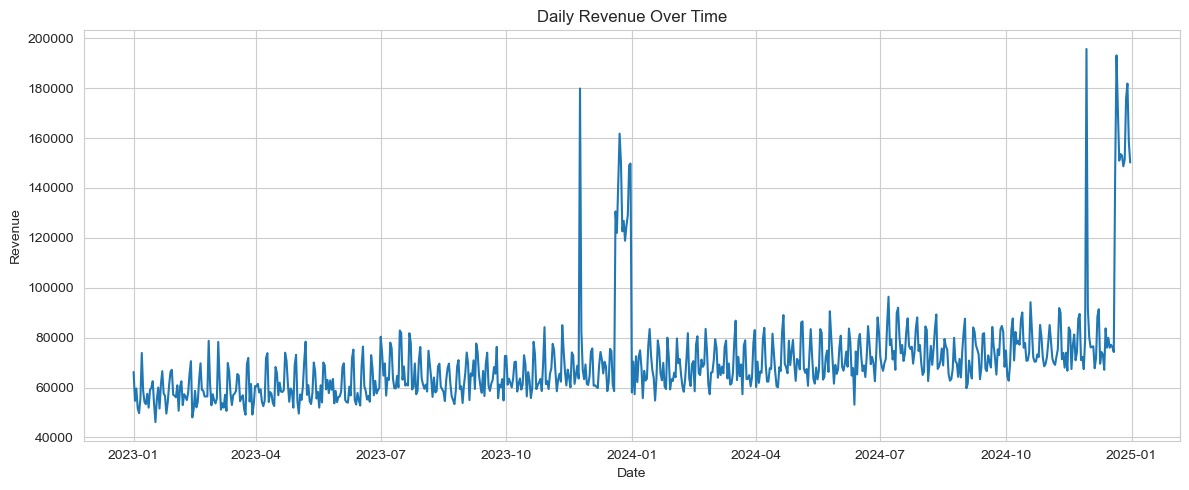

In [22]:
"""
Dataset Validation — Revenue Over Time
"""

daily_revenue = (
    orders
    .groupby("order_date")["order_value"]
    .sum()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=daily_revenue.index,
    y=daily_revenue.values
)

plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "../figures/dataset_validation/daily_revenue.png",
    dpi=300
)

plt.show()

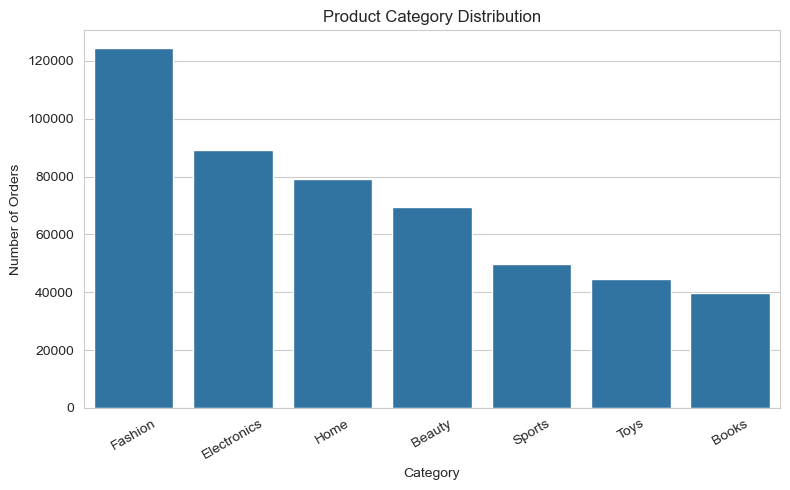

In [23]:
"""
Dataset Validation — Product Category Distribution
"""

plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x="product_category",
    order=orders["product_category"].value_counts().index
)

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../figures/dataset_validation/category_distribution.png",
    dpi=300
)

plt.show()

## Customer Aggregations

After generating the order-level dataset, we now compute **customer-level behavioral metrics**.

Aggregating transaction data at the customer level is a common step in e-commerce analytics.

These features are widely used for:

- customer segmentation
- churn prediction
- lifetime value modeling
- marketing targeting

### Transaction Metrics

We compute several key metrics:

- `total_orders`
- `total_spent`
- `average_order_value`

### Recency Metrics

We calculate:

- `days_since_last_purchase`

This measures how recently a customer has made a purchase.

### RFM Features

We also construct the classic **RFM variables**:

- **Recency** → how recently a customer purchased
- **Frequency** → how often they purchase
- **Monetary** → how much they spend

These features are extremely common in **customer analytics and marketing science**.

In [24]:
"""
Customer Aggregations — Transaction Metrics
"""

customer_orders = (
    orders
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "count"),
        total_spent=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

customer_orders.head()

,customer_id,total_orders,total_spent,average_order_value
0,1,51,5027.08,98.570196
1,2,76,8823.78,116.102368
2,3,16,2029.18,126.823750
3,4,21,1941.90,92.471429
4,5,53,6056.00,114.264151


In [25]:
"""
Customer Aggregations — Recency Calculation
"""

reference_date = orders["order_date"].max()

last_purchase = (
    orders
    .groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

last_purchase["days_since_last_purchase"] = (
    reference_date - last_purchase["order_date"]
).dt.days

last_purchase.head()

,customer_id,order_date,days_since_last_purchase
0,1,2024-12-29,2
1,2,2024-12-25,6
2,3,2024-12-29,2
3,4,2024-12-20,11
4,5,2024-12-24,7


In [26]:
"""
Merge Aggregated Features with Customer Dataset
"""

customers = customers.merge(
    customer_orders,
    on="customer_id",
    how="left"
)

customers = customers.merge(
    last_purchase[["customer_id", "days_since_last_purchase"]],
    on="customer_id",
    how="left"
)

# Handle customers with no orders
customers["total_orders"] = customers["total_orders"].fillna(0)
customers["total_spent"] = customers["total_spent"].fillna(0)
customers["average_order_value"] = customers["average_order_value"].fillna(0)

customers["days_since_last_purchase"] = customers[
    "days_since_last_purchase"
].fillna(N_DAYS)

customers.head()

,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216,0.369702,47.0,4547.73,96.760213,7.0
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138,0.493732,68.0,5440.13,80.001912,10.0
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699,0.320223,40.0,3978.12,99.453000,4.0
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599,0.575448,118.0,11282.80,95.616949,2.0
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583,0.136320,17.0,2259.21,132.894706,1.0


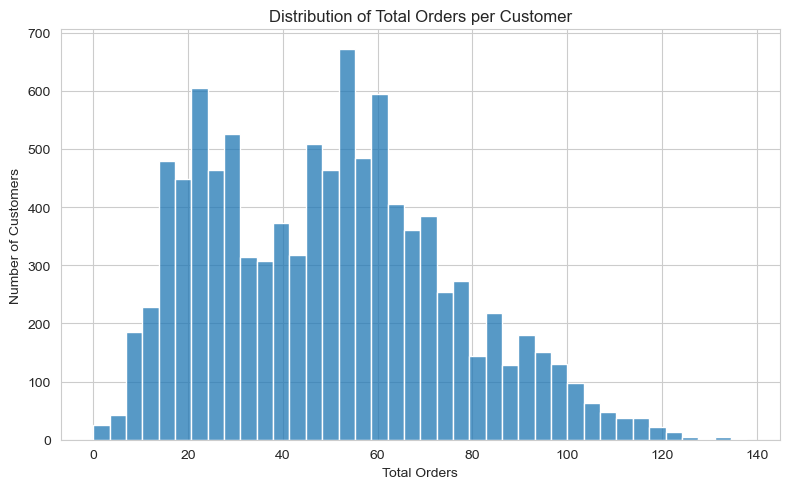

In [27]:
"""
Dataset Validation — Total Orders Distribution
"""

plt.figure(figsize=(8,5))

sns.histplot(
    customers["total_orders"],
    bins=40
)

plt.title("Distribution of Total Orders per Customer")
plt.xlabel("Total Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../figures/dataset_validation/customer_total_orders_distribution.png",
    dpi=300
)

plt.show()

## Dataset Quality Checks

Before exporting the dataset, we perform a series of **data quality validations**.

Data validation is an essential step in real-world data pipelines.

These checks help detect potential issues such as:

- missing values
- duplicate records
- unrealistic values
- inconsistent timestamps

Performing validation ensures that the dataset is **clean, reliable, and suitable for machine learning tasks**.

### Validation Steps

We perform the following checks:

- missing values per column
- duplicate records
- dataset summary statistics
- revenue sanity checks

In [28]:
"""
Dataset Quality Report
"""

print("DATASET QUALITY REPORT")
print("-" * 40)

print("\nDataset Sizes")
print("Customers:", len(customers))
print("Orders:", len(orders))


print("\nMissing Values (Customers)")
print(customers.isna().sum())

print("\nMissing Values (Orders)")
print(orders.isna().sum())


print("\nDuplicate Checks")
print("Duplicate customers:", customers["customer_id"].duplicated().sum())
print("Duplicate orders:", orders["order_id"].duplicated().sum())


print("\nRevenue Statistics")

total_revenue = orders["order_value"].sum()
avg_order_value = orders["order_value"].mean()
orders_per_customer = orders.groupby("customer_id").size().mean()

print("Total Revenue:", round(total_revenue,2))
print("Average Order Value:", round(avg_order_value,2))
print("Average Orders per Customer:", round(orders_per_customer,2))


print("\nSanity Checks")

print("Negative order values:", (orders["order_value"] < 0).sum())
print("Customers under age 18:", (customers["age"] < 18).sum())

DATASET QUALITY REPORT
----------------------------------------

Dataset Sizes
Customers: 10000
Orders: 495949

Missing Values (Customers)
customer_id                 0
signup_date                 0
age                         0
income                      0
country                     0
loyalty_member              0
website_visits              0
app_usage                   0
discount_usage              0
engagement_score            0
purchase_propensity         0
total_orders                0
total_spent                 0
average_order_value         0
days_since_last_purchase    0
dtype: int64

Missing Values (Orders)
order_id                   0
customer_id                0
order_date                 0
promotion                  0
holiday               450933
product_category           0
order_value                0
marketing_campaign         0
dtype: int64

Duplicate Checks
Duplicate customers: 0
Duplicate orders: 0

Revenue Statistics
Total Revenue: 51446433.33
Average Order Value:

In [29]:
"""
Export Final Datasets
"""

customers.to_csv(
    "../data/processed/customers.csv",
    index=False
)

orders.to_csv(
    "../data/processed/orders.csv",
    index=False
)

print("Datasets exported successfully.")

Datasets exported successfully.
